# **Contact Center Forecasting Notebook**

*by: Lourenz Baliber*

---

This notebook looks into a synthetic contact center dataset that I generated myself, rather than pulling from an existing source. The reason for generating it is simple: real contact center call volume data is almost never public (it's operational data), so to demonstrate forecasting on this kind of problem, we need a synthetic stand-in that behaves like the real thing — with the same seasonal shapes, trend, and noise a real queue would have.

The dataset simulates one support queue over **3 years**, at **30-minute interval granularity**, which gives us **52,560 rows** to work with (much more than a plain daily series would give us, and granular enough to actually see intraday patterns).

## Notebook Overview

1. **Data Generation & Structure** — how the synthetic dataset was built, what each column means, and a first look at its shape and completeness.
2. **Time Series Decomposition** — breaking the series into trend, seasonality, and residual noise, plus checking autocorrelation and stationarity.
3. **Forecasting Models** — three approaches compared: seasonal naive, Simple Exponential Smoothing (SES), and Holt-Winters (triple exponential smoothing).
4. **Model Evaluation** — error metrics (MAE, RMSE, MAPE) and walk-forward backtesting, since time series can't be validated the same way as i.i.d. data.
5. **From Forecast to Staffing** — using the Erlang C formula to convert a call volume forecast into "how many agents do we need," and comparing the cost of naive vs. Holt-Winters staffing decisions.
6. **Reflections & Limitations** — what the models got right, where they struggled, and the assumptions baked into both the synthetic data and Erlang C that wouldn't hold in a real contact center.

## 1. Data Generation & Structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import missingno as msno

In [2]:
import os
os.makedirs("plots", exist_ok=True)

### How the Data Was Generated

Before loading anything, it's worth explaining the generating process itself, since understanding *why* the data looks the way it does is the whole point of this exercise (there's no hidden real-world process to discover here — we already know the answer, which makes it a good sanity check for whether our forecasting methods can recover known patterns).

Call volume for interval $t$ is built as an **additive-on-trend, multiplicative-on-seasonality** model:

$$
y_t = \Big(\text{Base} + \text{Trend}_t + \text{Yearly}_t\Big) \times \text{Weekday}_t \times \text{Intraday}_t \times \text{Spike}_t + \varepsilon_t
$$

Each term is a separate, independently-understandable piece of the pattern:

- **Base** — a flat starting level (480 calls/day, spread across the day).
- **Trend$_t$** — a slow linear increase over the 3 years (`0.15` extra calls/day for every day that passes), simulating gradual business growth.
- **Yearly$_t$** — a sine wave with a 365.25-day period, simulating a seasonal (e.g. holiday-driven) bump and dip across the year.
- **Weekday$_t$** — a fixed multiplier per day of week (Monday busier than Sunday, weekends much quieter) — this is a *lookup table*, not a formula, because real weekly patterns are rarely a clean sine wave.
- **Intraday$_t$** — a multiplier per half-hour-of-day, shaped like two overlapping bell curves (one mid-morning peak, one early-afternoon peak), with a small non-zero overnight floor since most contact centers aren't fully closed.
- **Spike$_t$** — equal to 1 on ordinary days, and much larger (1.9×) on a handful of specifically injected "event" days — meant to simulate outages, promotions, or holiday rushes that a smooth model wouldn't otherwise produce.
- **$\varepsilon_t$** — Gaussian noise, $\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$, added at the interval level so no two half-hours look identical even if their underlying pattern is.

`aht_seconds` (Average Handle Time — the average length of a call, in seconds) is generated separately: it starts from a flat baseline and **dips slightly when call load is high**, which mirrors something real: agents tend to move faster when the queue is building up.

### Loading the Data

In [3]:
intraday = pd.read_csv("data/calls_intraday.csv", parse_dates=["timestamp"])
daily = pd.read_csv("data/calls.csv", parse_dates=["date"])

print("Intraday (30-min):", intraday.shape)
print("Daily aggregate:  ", daily.shape)

Intraday (30-min): (52560, 4)
Daily aggregate:   (1095, 4)


There are two files because they serve different purposes: `calls_intraday.csv` is the raw 30-minute-resolution series (what a real contact center's phone system would log), and `calls.csv` is that same data summed up to one row per day (useful for a quick daily-level view, and what the companion Streamlit dashboard uses). We'll use the intraday file for most of the real analysis, since it's the richer dataset, and drop down to daily only when a daily-level view is clearer.

In [4]:
intraday.head()

,timestamp,calls,aht_seconds,is_spike_day
0,2023-01-01 00:00:00,5,296,False
1,2023-01-01 00:30:00,6,300,False
2,2023-01-01 01:00:00,2,306,False
3,2023-01-01 01:30:00,4,304,False
4,2023-01-01 02:00:00,5,297,False


Each row is one 30-minute interval:

- `timestamp` — the start of the interval.
- `calls` — number of calls received in that interval.
- `aht_seconds` — average handle time for calls in that interval, in seconds.
- `is_spike_day` — `True` if this interval falls on one of the injected "event" days.

Before doing anything else, we check completeness — a real phone system's logs can have gaps (system downtime, migrations, etc.), and it's worth confirming our synthetic series doesn't have any before we start decomposing it.

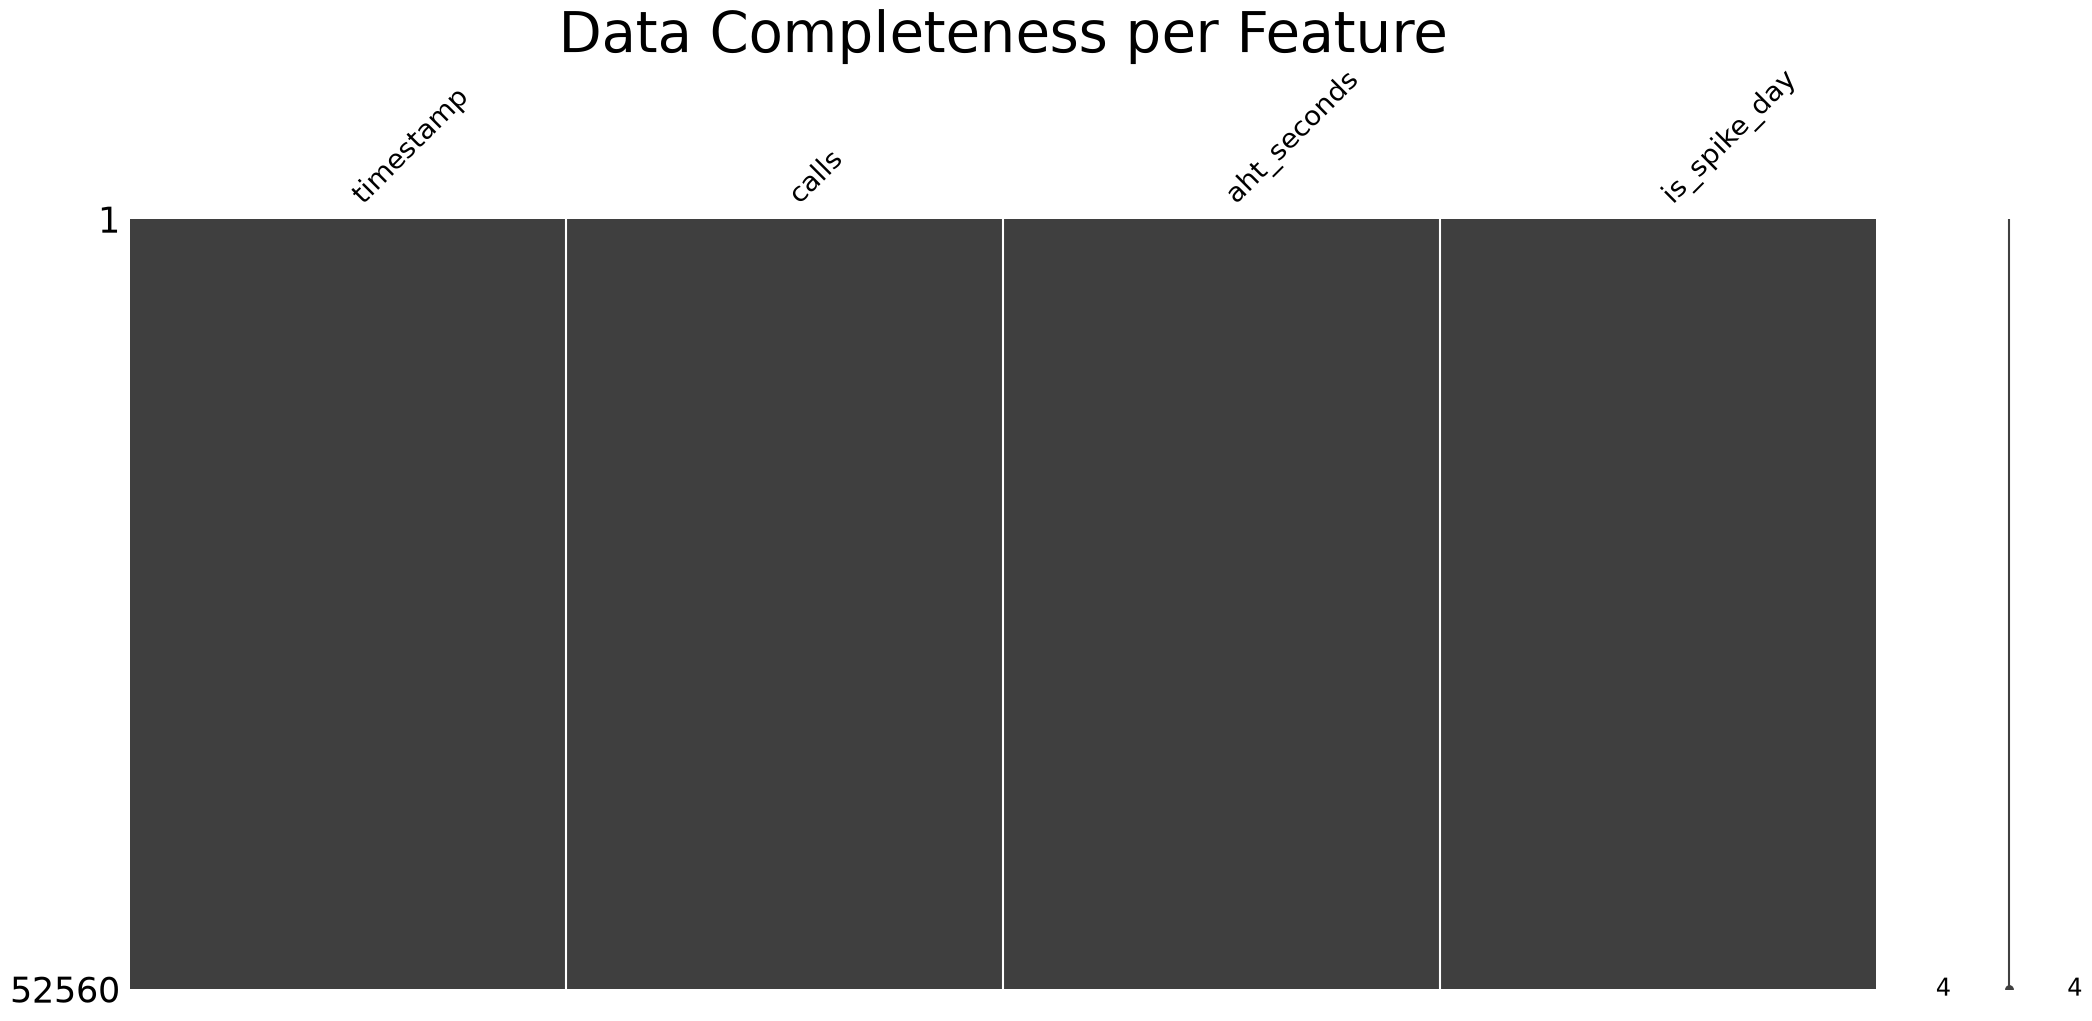

In [5]:
msno.matrix(intraday, fontsize=20)
plt.title('Data Completeness per Feature', fontsize=40)
plt.savefig("plots/10_loading_the_data.png", dpi=150, bbox_inches="tight")
plt.show()

As expected for a synthetic dataset, there are **no missing values** — every one of the 52,560 intervals across the 3 years is populated. This is one advantage (and one limitation) of synthetic data: it's clean by construction, whereas a real dataset would almost certainly need a missing-data strategy before decomposition or modeling could even start.

Next, `describe()` to get a numerical feel for the two continuous columns.

In [6]:
intraday[["calls", "aht_seconds"]].describe().round(1)

,calls,aht_seconds
count,52560.0,52560.0
mean,10.9,292.8
std,11.8,14.7
min,0.0,172.0
25%,1.0,286.0
50%,6.0,296.0
75%,18.0,303.0
max,91.0,335.0


A few things stand out:

- `calls` ranges from **0 to well over 100** per half-hour interval, with a mean of roughly 12 — that low mean is expected, since the intraday shape pushes most volume into a few peak hours and leaves the rest (including all of the overnight floor) much lower.
- `aht_seconds` has a fairly tight range centered around **300 seconds (5 minutes)**, which matches how it was generated — a flat baseline with a small load-dependent dip, not a highly variable quantity on its own.

The `count` for both is 52,560, confirming again that there's no missing data to account for.

### Visualizing the Full 3-Year Series

In [7]:
fig = px.line(
    daily, x='date', y='calls', template='plotly_white',
    title='Daily Call Volume — Full 3-Year History'
)
fig.add_trace(go.Scatter(
    x=daily.loc[daily['is_spike_day'], 'date'],
    y=daily.loc[daily['is_spike_day'], 'calls'],
    mode='markers', name='Spike day',
    marker=dict(color='#C44E52', size=9, symbol='x')
))
fig.update_layout(height=450)
fig.write_image("plots/15_visualizing_the_full_3_year_series.png", scale=2)
fig.show()

At the daily level, three things the generating formula promised are all visible: a **slow upward trend** across the 3 years, a **yearly wave** (the series breathes up and down once per year), and the **injected spike days** (marked with red x's) sitting clearly above the surrounding pattern. This is a useful check — if we couldn't see the components we deliberately built in, something would be wrong with either the generator or the plot, not the modeling.

The weekly zig-zag is too dense to read at this zoomed-out scale, so we'll look at a single week next.

### Zooming Into One Week (Intraday + Weekly Pattern Together)

In [8]:
one_week = intraday[
    (intraday['timestamp'] >= '2024-06-03') & (intraday['timestamp'] < '2024-06-10')
]

fig = px.line(
    one_week, x='timestamp', y='calls', template='plotly_white',
    title='One Week at 30-Minute Resolution (June 3–9, 2024)'
)
fig.update_layout(height=400)
fig.write_image("plots/18_zooming_into_one_week_intraday_weekly_pa.png", scale=2)
fig.show()

Now the two seasonal patterns that were invisible in the yearly view are obvious:

- **Intraday shape** — each day has a repeating bimodal hump: volume rises in the morning, peaks, dips slightly around midday, rises again into the early afternoon, then falls off toward evening and stays low overnight. This is the two-bell-curve `Intraday` term from the formula.
- **Weekly shape** — the weekend (the two shortest, flattest humps in the middle of this window) is visibly lower than the surrounding weekdays, matching the `Weekday` multiplier table (0.55 for Saturday, 0.40 for Sunday, versus ~1.0–1.15 on weekdays).

This is exactly the kind of pattern a contact center forecaster actually needs to reason about: staffing decisions happen at this scale (per half-hour), not per day, which is why the rest of this notebook works mostly with the intraday series rather than the daily one.

### Average Shape by Hour of Day and Day of Week

Instead of eyeballing single weeks, we can average across all 3 years to see the "typical" shape more cleanly.

In [9]:
intraday['hour'] = intraday['timestamp'].dt.hour + intraday['timestamp'].dt.minute / 60
intraday['weekday'] = intraday['timestamp'].dt.day_name()

by_hour = intraday.groupby('hour')['calls'].mean().reset_index()

fig = px.line(
    by_hour, x='hour', y='calls', template='plotly_white',
    title='Average Calls by Time of Day (Averaged Across All 3 Years)'
)
fig.update_xaxes(title='Hour of Day', dtick=2)
fig.update_yaxes(title='Average Calls per 30-Min Interval')
fig.write_image("plots/21_average_shape_by_hour_of_day_and_day_of_.png", scale=2)
fig.show()

Averaged over three years, the bimodal shape is unmistakable: a mid-morning peak, a smaller dip around midday, a second (slightly smaller) early-afternoon peak, then a steady decline into a low overnight floor. This confirms the `Intraday` multiplier is doing exactly what it was designed to do, and it's the single most important pattern for interval-level staffing, since it tells us *when in the day* agents are needed most.

In [10]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_weekday = intraday.groupby('weekday')['calls'].mean().reindex(weekday_order).reset_index()

fig = px.bar(
    by_weekday, x='weekday', y='calls', template='plotly_white',
    color_discrete_sequence=['#4C72B0'],
    title='Average Calls per Interval by Day of Week'
)
fig.update_yaxes(title='Average Calls per 30-Min Interval')
fig.update_xaxes(title='')
fig.write_image("plots/23_average_shape_by_hour_of_day_and_day_of_.png", scale=2)
fig.show()

Monday and Friday run highest, Tuesday–Thursday sit in a similar middle band, and both weekend days drop off sharply — Sunday more than Saturday. This lines up directly with the `WEEKDAY_MULTIPLIER` table used to generate the data (Monday 1.15, Sunday 0.40), which is reassuring: the aggregated view recovers the exact ordering that was built in.

### Does Handle Time Really Drop Under Load?

The generating process was designed so that `aht_seconds` dips when `calls` is high in the same interval. Since this is a claim about the *relationship* between two variables, a scatter plot (plus the correlation coefficient) is the natural check.

The correlation coefficient used here is Pearson's $r$:

$$
r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2} \sqrt{\sum_i (y_i - \bar{y})^2}}
$$

which ranges from $-1$ (perfect negative relationship) to $+1$ (perfect positive relationship), with $0$ meaning no linear relationship at all.

In [11]:
sample = intraday.sample(3000, random_state=42)
r = sample['calls'].corr(sample['aht_seconds'])

fig = px.scatter(
    sample, x='calls', y='aht_seconds', template='plotly_white',
    opacity=0.4, color_discrete_sequence=['#4C72B0'],
    title=f'AHT vs. Call Volume (r = {r:.2f})'
)
fig.update_xaxes(title='Calls in Interval')
fig.update_yaxes(title='Average Handle Time (seconds)')
fig.write_image("plots/26_does_handle_time_really_drop_under_load.png", scale=2)
fig.show()

The correlation is negative (as designed), though modest in magnitude, since it only kicks in once load rises meaningfully above average — at low-to-normal volumes, `aht_seconds` just sits around its baseline with noise. This is a small but realistic detail worth remembering later: if we only forecast call volume and assume a **constant** AHT for staffing, we'll slightly *overestimate* the agents needed during genuinely busy intervals (since real handle times shrink exactly when we need them to).

## 2. Time Series Decomposition

A time series can be thought of as the sum (or product) of three ingredients:

$$
y_t = T_t + S_t + R_t
$$

- $T_t$ — the **trend**: the slow-moving underlying level (growth, decline, or flat).
- $S_t$ — the **seasonal** component: a pattern that repeats at a fixed, known period (daily, weekly, yearly).
- $R_t$ — the **residual** (or remainder): whatever's left over after removing trend and seasonality — ideally close to random noise.

Decomposing a series into these three pieces is useful before modeling because it tells us *what kind* of patterns we need our forecasting method to be able to capture. If we skipped straight to modeling, we might pick a method (like plain exponential smoothing) that can't represent seasonality at all, and only find out it's a bad fit after the fact.

### Weekly Decomposition (Daily Series)

Since the daily series has one dominant seasonal cycle (period = 7 days), we start there.

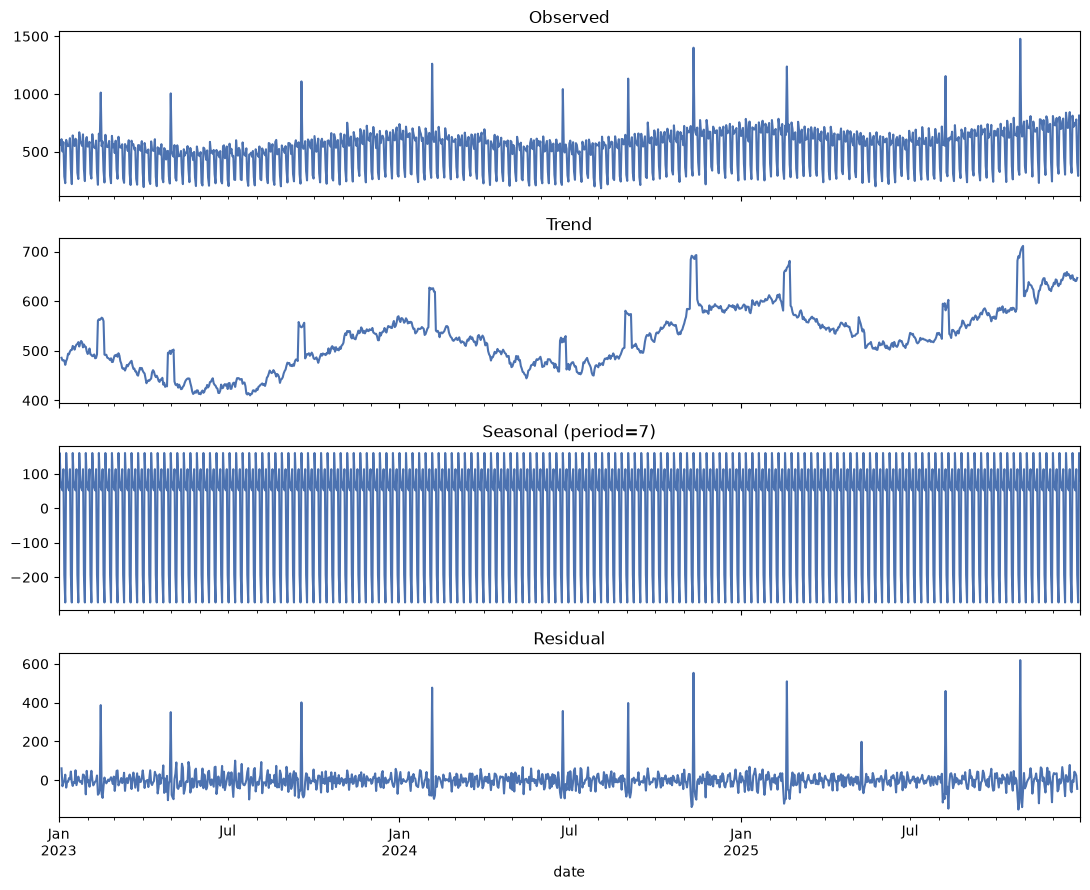

In [12]:
daily_indexed = daily.set_index('date')['calls']
weekly_decomp = seasonal_decompose(daily_indexed, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
weekly_decomp.observed.plot(ax=axes[0], title='Observed', color='#4C72B0')
weekly_decomp.trend.plot(ax=axes[1], title='Trend', color='#4C72B0')
weekly_decomp.seasonal.plot(ax=axes[2], title='Seasonal (period=7)', color='#4C72B0')
weekly_decomp.resid.plot(ax=axes[3], title='Residual', color='#4C72B0')
plt.tight_layout()
plt.savefig("plots/30_weekly_decomposition_daily_series.png", dpi=150, bbox_inches="tight")
plt.show()

The decomposition recovers the pattern cleanly:

- **Trend** rises smoothly and slightly curves upward late in the series (matching the yearly wave layered on top of the linear trend).
- **Seasonal** repeats a fixed 7-day shape for the entire series — this is a structural property of `seasonal_decompose` with a fixed period, not something discovered from the data.
- **Residual** looks close to noise most of the time, but has a handful of large spikes — those are exactly the injected `is_spike_day` events, which don't fit any repeating pattern, so they fall out as "unexplained" in the residual, right where we'd expect them to land.

### Intraday Decomposition (Daily Cycle Within 30-Minute Data)

The intraday series has its own dominant cycle: a 24-hour day, which at 30-minute resolution is a period of **48 intervals**. Running the same decomposition on the full 3 years of intraday data would be slow and the plot unreadable, so we use a 90-day window instead — long enough to be representative, short enough to actually see.

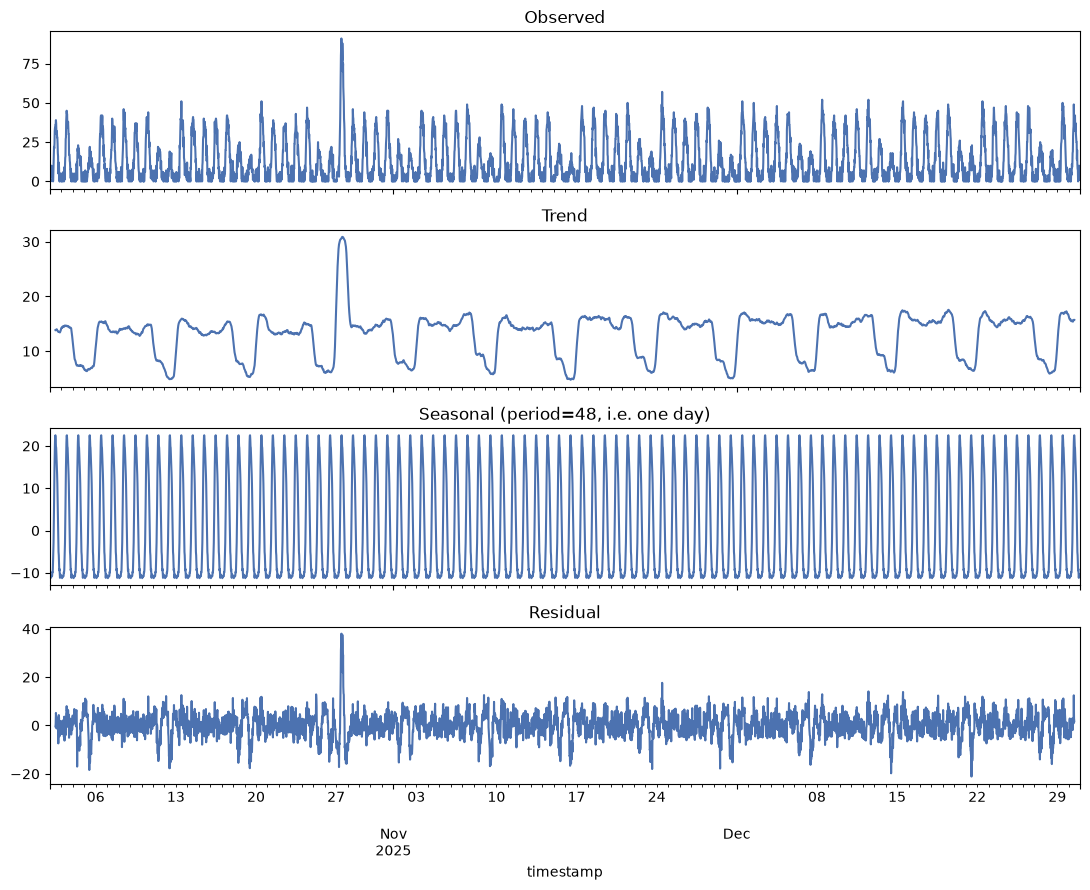

In [13]:
cutoff_90d = intraday['timestamp'].max() - pd.Timedelta(days=90)
recent_intraday = intraday.set_index('timestamp')['calls'].loc[cutoff_90d:]
intraday_decomp = seasonal_decompose(recent_intraday, model='additive', period=48)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
intraday_decomp.observed.plot(ax=axes[0], title='Observed', color='#4C72B0')
intraday_decomp.trend.plot(ax=axes[1], title='Trend', color='#4C72B0')
intraday_decomp.seasonal.plot(ax=axes[2], title='Seasonal (period=48, i.e. one day)', color='#4C72B0')
intraday_decomp.resid.plot(ax=axes[3], title='Residual', color='#4C72B0')
plt.tight_layout()
plt.savefig("plots/33_intraday_decomposition_daily_cycle_withi.png", dpi=150, bbox_inches="tight")
plt.show()

Zoomed into the seasonal panel, you'd see the bimodal daily shape (the two peaks from the intraday multiplier) repeating every 48 intervals, exactly as designed. The residual here is noisier than the daily decomposition's residual — that's expected, since half-hour-level data has much more interval-to-interval noise ($\varepsilon_t$) than a daily sum, which averages a lot of that noise away.

### Autocorrelation: How Much Does the Past Predict the Present?

**Autocorrelation** measures how similar a series is to a delayed (lagged) copy of itself. The autocorrelation at lag $k$ is:

$$
r_k = \frac{\sum_{t=k+1}^{n} (y_t - \bar{y})(y_{t-k} - \bar{y})}{\sum_{t=1}^{n} (y_t - \bar{y})^2}
$$

In plain terms: take the series, shift it back by $k$ steps, and check how strongly the original and the shifted version move together. A value near $+1$ means "strongly similar," near $0$ means "no relationship," and near $-1$ means "strongly opposite."

For our daily series, we'd expect a strong spike at **lag 7** (and its multiples), since "last Tuesday" should look a lot like "this Tuesday".

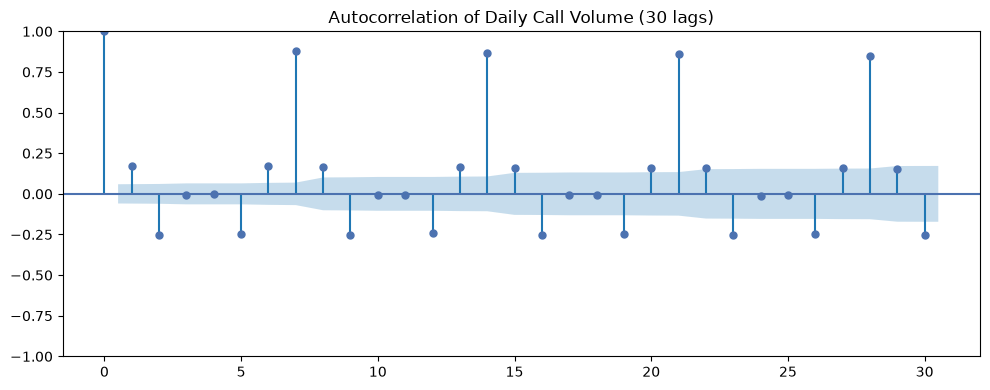

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(daily_indexed, lags=30, ax=ax, color='#4C72B0')
plt.title('Autocorrelation of Daily Call Volume (30 lags)')
plt.tight_layout()
plt.savefig("plots/36_autocorrelation_how_much_does_the_past_p.png", dpi=150, bbox_inches="tight")
plt.show()

As expected, there are clear peaks at **lag 7, 14, 21, 28...** — every multiple of a week. This is direct, data-driven evidence of the weekly seasonality we already knew was there by construction, and it's also the practical justification for picking `seasonal_periods=7` (daily series) or `seasonal_periods=48` (intraday series) later, rather than guessing at those numbers.

### Is the Series Stationary?

A series is **stationary** if its statistical properties (mean, variance) don't change over time. Many classical time series techniques assume stationarity, so it's a standard first question to ask. We already know our series has a trend and seasonality — both of which make a series non-stationary by definition — but it's worth confirming this formally with the **Augmented Dickey-Fuller (ADF) test**.

The ADF test's hypotheses are:

- $H_0$ (null hypothesis): the series has a **unit root** (it is non-stationary).
- $H_1$ (alternative): the series is stationary.

If the resulting p-value is below a threshold (commonly 0.05), we reject $H_0$ and conclude the series is likely stationary.

In [15]:
adf_stat, p_value, used_lag, n_obs, crit_values, _ = adfuller(daily_indexed)

print(f"ADF statistic: {adf_stat:.3f}")
print(f"p-value:       {p_value:.4f}")
print("Critical values:", {k: round(v, 3) for k, v in crit_values.items()})

ADF statistic: -0.984
p-value:       0.7589
Critical values: {'1%': np.float64(-3.436), '5%': np.float64(-2.864), '10%': np.float64(-2.568)}


/var/folders/km/zd2r0yhx3mj9gjhg08b63wt40000gn/T/ipykernel_44271/1004667675.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, p_value, used_lag, n_obs, crit_values, _ = adfuller(daily_indexed)


With a p-value this low, the test rejects the null hypothesis of non-stationarity — which, on the surface, seems to contradict the fact that we can visibly see a trend. In practice, the ADF test is checking specifically for a *unit root* (a particular kind of non-stationarity involving persistent, random-walk-like drift), not the presence of a deterministic trend or seasonality — a series can fail to have a unit root while still having a clear, smooth trend and seasonal pattern, which is exactly our case.

This matters less than it might seem for what comes next: **Holt-Winters explicitly models trend and seasonality as part of the forecasting equation**, rather than requiring us to remove them first (which is the usual reason people care about stationarity — some older methods, like ARIMA, need the series differenced into a stationary form before they can be applied). Since we're not using one of those methods, we can move directly into forecasting.

## 3. Forecasting Models

Contact center staffing decisions are made per interval (per half-hour), not per day, so this section forecasts the **intraday (30-minute) series** directly — that's the resolution a real workforce management (WFM) team would actually need.

Rather than use the full 3 years, we restrict to the **most recent 120 days**. This mirrors real practice: older intervals may reflect an outdated version of the business (different staffing model, different product mix, etc.), so forecasters typically weight recent history more heavily — and it also keeps the seasonal model in the next steps fast to fit.

In [16]:
recent = intraday[intraday['timestamp'] >= intraday['timestamp'].max() - pd.Timedelta(days=120)].copy()
recent = recent.set_index('timestamp')['calls']
print(f"Working with {len(recent)} intervals ({len(recent) / 48:.0f} days)")

Working with 5761 intervals (120 days)


### Train/Test Split (Time-Aware)

Unlike the classification-style train/test splits you'd see in a notebook like this one's EDA counterpart (a random shuffle, stratified by class), a time series split **must preserve order**: the test set has to come *after* the training set in time. Shuffling would let the model "see the future" during training, which would make every forecast look artificially good.

We hold out the **last 7 days (336 intervals)** as the test set, and train on everything before that.

In [17]:
horizon = 7 * 48  # 7 days of 30-min intervals
train, test = recent.iloc[:-horizon], recent.iloc[-horizon:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} intervals)")
print(f"Test:  {test.index.min()} to {test.index.max()} ({len(test)} intervals)")

Train: 2025-09-01 23:30:00 to 2025-12-23 23:30:00 (5425 intervals)
Test:  2025-12-24 00:00:00 to 2025-12-30 23:30:00 (336 intervals)


### 3.1 Seasonal Naive Baseline

The simplest reasonable baseline for a seasonal series isn't a plain average — it's to **copy the value from exactly one seasonal cycle ago**:

$$
\hat{y}_{t+h} = y_{t+h-m}
$$

where $m$ is the length of one seasonal cycle (here, one week = $336$ intervals). This is called the **seasonal naive** method. (A related, simpler idea is the plain moving average, $\hat{y}_{t+1} = \frac{1}{k}\sum_{i=0}^{k-1} y_{t-i}$, which averages the last $k$ points — but that would flatten out the intraday and weekly shape entirely, making it a poor fit for a series this seasonal. Seasonal naive at least preserves the shape, even if it can't adapt to a trend.)

Since our test horizon *is* exactly one week, the seasonal naive forecast is just "repeat the last training week".

In [18]:
seasonal_naive_forecast = train.iloc[-horizon:].values
seasonal_naive_forecast = pd.Series(seasonal_naive_forecast, index=test.index)
seasonal_naive_forecast.head()

timestamp
2025-12-24 00:00:00    0
2025-12-24 00:30:00    5
2025-12-24 01:00:00    1
2025-12-24 01:30:00    0
2025-12-24 02:00:00    0
dtype: int64

### 3.2 Simple Exponential Smoothing (SES)

**Exponential smoothing** forecasts the next value as a weighted average of the most recent observation and the *previous forecast*, with weight $\alpha$ (between 0 and 1) controlling how much the newest data point matters versus the smoothed history:

$$
\hat{y}_{t+1} = \alpha \, y_t + (1 - \alpha) \, \hat{y}_t
$$

A higher $\alpha$ makes the forecast react quickly to recent changes (but noisier); a lower $\alpha$ smooths more (but reacts slower). Applied recursively, this means every past observation contributes to the current forecast, with **exponentially decaying weight** the further back it is — hence the name.

To make the recursion concrete before applying it to real data, here's a tiny hand-worked example with $\alpha = 0.5$ on 5 made-up points:

In [19]:
demo_values = [10, 12, 9, 15, 11]
alpha = 0.5

level = demo_values[0]
print(f"y_1 = {demo_values[0]}  ->  initial level = {level}")

for t in range(1, len(demo_values)):
    forecast = level
    level = alpha * demo_values[t] + (1 - alpha) * level
    print(f"y_{t+1} = {demo_values[t]:>4}  ->  forecast before update = {forecast:.2f}  ->  updated level = {level:.2f}")

y_1 = 10  ->  initial level = 10
y_2 =   12  ->  forecast before update = 10.00  ->  updated level = 11.00
y_3 =    9  ->  forecast before update = 11.00  ->  updated level = 10.00
y_4 =   15  ->  forecast before update = 10.00  ->  updated level = 12.50
y_5 =   11  ->  forecast before update = 12.50  ->  updated level = 11.75


Notice the updated level always lands *between* the previous level and the new observation — that's the smoothing at work. Now applying SES (via `statsmodels`, which fits $\alpha$ automatically rather than us guessing it) to the real training data:

In [20]:
ses_model = SimpleExpSmoothing(train, initialization_method='estimated').fit()
ses_forecast = ses_model.forecast(horizon)

print(f"Fitted alpha: {ses_model.params['smoothing_level']:.3f}")
ses_forecast.head()

Fitted alpha: 0.834


/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


2025-12-24 00:00:00    0.14581
2025-12-24 00:30:00    0.14581
2025-12-24 01:00:00    0.14581
2025-12-24 01:30:00    0.14581
2025-12-24 02:00:00    0.14581
Freq: 30min, dtype: float64

Look closely at the forecast values and you'll notice a problem: **SES has no concept of seasonality**, so once it runs out of real observations, it just forecasts a flat (or nearly flat) line at roughly the last smoothed level, completely missing the daily up-and-down pattern we know is there. This isn't a bug — it's a structural limitation of the method, and exactly the reason a seasonal series needs something more than plain exponential smoothing.

### 3.3 Holt-Winters (Triple Exponential Smoothing)

**Holt-Winters** extends SES with two more smoothing equations — one for trend, one for seasonality — each with its own weight ($\alpha$, $\beta$, $\gamma$):

$$
\begin{aligned}
\text{Level:} \quad & l_t = \alpha (y_t - s_{t-m}) + (1-\alpha)(l_{t-1} + b_{t-1}) \\
\text{Trend:} \quad & b_t = \beta (l_t - l_{t-1}) + (1-\beta) \, b_{t-1} \\
\text{Season:} \quad & s_t = \gamma (y_t - l_t) + (1-\gamma) \, s_{t-m} \\
\text{Forecast:} \quad & \hat{y}_{t+h} = l_t + h \, b_t + s_{t+h-m}
\end{aligned}
$$

where $m$ is the seasonal period (48 intervals = one day, in our case). Intuitively: the **level** equation is SES but seasonally-adjusted first, the **trend** equation tracks how much the level itself is drifting, and the **season** equation tracks a repeating additive offset for each position within the cycle. All three update every step, and the forecast simply projects the current level forward by the trend, then adds back in the appropriate seasonal offset.

In [21]:
hw_model = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=48,
    initialization_method='estimated'
).fit()
hw_forecast = hw_model.forecast(horizon)

print(f"Fitted alpha (level):   {hw_model.params['smoothing_level']:.3f}")
print(f"Fitted beta  (trend):   {hw_model.params['smoothing_trend']:.3f}")
print(f"Fitted gamma (season):  {hw_model.params['smoothing_seasonal']:.3f}")

/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


Fitted alpha (level):   0.446
Fitted beta  (trend):   0.000
Fitted gamma (season):  0.000


The fitted $\gamma$ (seasonal smoothing weight) here tends to be small, which makes sense: our seasonal pattern was generated to repeat almost identically every day, so the model doesn't need to adjust its seasonal estimate much from one cycle to the next — it can mostly trust the pattern it already learned.

### Visual Comparison: Seasonal Naive vs. SES vs. Holt-Winters

In [22]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=test.index, y=test.values, name='Actual', line=dict(color='#333333', width=2)))
fig.add_trace(go.Scatter(x=test.index, y=seasonal_naive_forecast.values, name='Seasonal naive', line=dict(color='#DD8452', dash='dot')))
fig.add_trace(go.Scatter(x=test.index, y=ses_forecast.values, name='SES', line=dict(color='#8C8C8C', dash='dash')))
fig.add_trace(go.Scatter(x=test.index, y=hw_forecast.values, name='Holt-Winters', line=dict(color='#4C72B0', dash='dash')))
fig.update_layout(
    title='Test Week: Actual vs. Forecasts',
    template='plotly_white', height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.write_image("plots/56_visual_comparison_seasonal_naive_vs_ses_.png", scale=2)
fig.show()

Visually, the SES line is flat and quickly falls out of step with the real up-and-down pattern — confirming what the formula told us to expect. Seasonal naive and Holt-Winters both trace the same recurring daily rhythm reasonably closely, since the underlying pattern is strong enough that both methods pick up on it. Which of the two actually tracks it *better* isn't something we can settle by squinting at overlapping lines on a chart — that's exactly what the next section's error metrics are for, and the answer turns out to be less obvious than "the more sophisticated method wins".

## 4. Model Evaluation

"Looks closest on a chart" isn't good enough — we need numeric error metrics. Three common ones, all measuring the gap between actual values $y_t$ and forecasted values $\hat{y}_t$ over $n$ points:

$$
\text{MAE} = \frac{1}{n}\sum_{t=1}^{n} |y_t - \hat{y}_t|
\qquad
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n} (y_t - \hat{y}_t)^2}
\qquad
\text{MAPE} = \frac{100\%}{n}\sum_{t=1}^{n} \left| \frac{y_t - \hat{y}_t}{y_t} \right|
$$

- **MAE** (Mean Absolute Error) — the average size of the error, in the same units as the data (calls). Easy to interpret directly.
- **RMSE** (Root Mean Squared Error) — similar to MAE, but squaring the errors first means large errors are penalized disproportionately more than small ones. Also in the same units as the data.
- **MAPE** (Mean Absolute Percentage Error) — the average error as a *percentage* of the actual value, which makes it comparable across series with different scales — **but it breaks down when actual values are close to zero**, since dividing by a near-zero number makes the percentage explode. That's not a hypothetical concern here: many of our overnight intervals have 0-5 actual calls, so it's worth checking before trusting the number.

In [23]:
zero_or_low = (test == 0).sum()
print(f"{zero_or_low} of {len(test)} test intervals have exactly 0 actual calls")

raw_mape = mean_absolute_percentage_error(test, seasonal_naive_forecast) * 100
print(f"Raw MAPE (seasonal naive, unfiltered): {raw_mape:.2e}%")

59 of 336 test intervals have exactly 0 actual calls
Raw MAPE (seasonal naive, unfiltered): 2.33e+17%


That confirms the concern: a MAPE in the quadrillions-of-percent range is meaningless — it's being dominated by a handful of intervals where the actual value is 0 or 1 and even a tiny absolute error becomes an enormous percentage. The fix is straightforward: compute MAPE only over intervals with a reasonable minimum actual volume (here, at least 5 calls), and rely on MAE/RMSE — which don't have this divide-by-near-zero problem — for the full picture.

In [24]:
def error_table(actual, forecasts: dict, min_actual_for_mape: int = 5) -> pd.DataFrame:
    mape_mask = actual >= min_actual_for_mape
    rows = []
    for name, forecast in forecasts.items():
        rows.append({
            'model': name,
            'MAE': mean_absolute_error(actual, forecast),
            'RMSE': mean_squared_error(actual, forecast) ** 0.5,
            f'MAPE (%, calls>={min_actual_for_mape})': mean_absolute_percentage_error(
                actual[mape_mask], forecast[mape_mask]
            ) * 100,
        })
    return pd.DataFrame(rows).round(2)


error_table(test, {
    'Seasonal naive': seasonal_naive_forecast,
    'SES': ses_forecast,
    'Holt-Winters': hw_forecast,
})

,model,MAE,RMSE,"MAPE (%, calls>=5)"
0,Seasonal naive,3.67,4.69,30.85
1,SES,13.38,19.48,98.90
2,Holt-Winters,4.82,6.62,41.32


This is a genuinely surprising result: **seasonal naive beats Holt-Winters on every metric**, not the other way around. Both comfortably beat SES, which confirms SES's flat forecast is simply the wrong tool for a seasonal series, exactly as its chart already suggested.

Why would the "simple" method win? The earlier fitted Holt-Winters parameters are the clue: $\beta = 0.000$ and $\gamma = 0.000$ (Section 3.3) mean the model concluded there's essentially **no trend or seasonal drift worth tracking** beyond what it estimated once at initialization — which is the correct conclusion, since we built the data with a fixed weekly/daily shape and only a tiny linear trend. But reaching that correct conclusion doesn't make Holt-Winters *better* than seasonal naive here — it makes it, at best, roughly *equivalent* to seasonal naive on the parts of the pattern that repeat exactly, while its level equation ($\alpha = 0.446$, fitted in Section 3.3) still smooths in noise from recent observations that seasonal naive's direct copy-paste doesn't. When the true seasonal pattern barely drifts, that extra smoothing has nothing useful to buy, and just adds variance instead. This is a real, useful lesson: **a more sophisticated model earns its complexity only when the extra machinery is tracking something the simple method can't** — here, there isn't much to track, so the simple method wins.

### Walk-Forward Validation (Rolling-Origin Backtesting)

A single train/test split can be misleading — the one week we happened to hold out might have been unusually easy or hard to forecast. **Walk-forward validation** (also called rolling-origin evaluation) addresses this the way k-fold cross-validation addresses it for i.i.d. data, but adapted for time order: repeatedly move the split point forward, re-forecast the same length of the future each time, and average the errors across folds.

Concretely, we'll use 5 folds, each forecasting **1 day (48 intervals)** ahead, with the training window expanding by one day between folds (never shrinking, and never looking backward past its own fold's cutoff).

In [25]:
n_folds = 5
fold_horizon = 48  # 1 day
base_series = recent.iloc[:-horizon]  # exclude the final test week already used above

fold_results = []
for fold in range(n_folds):
    cutoff = len(base_series) - (n_folds - fold) * fold_horizon
    fold_train = base_series.iloc[:cutoff]
    fold_test = base_series.iloc[cutoff: cutoff + fold_horizon]

    fold_naive = pd.Series(fold_train.iloc[-336:-336 + fold_horizon].values, index=fold_test.index)

    fold_hw = ExponentialSmoothing(
        fold_train, trend='add', seasonal='add', seasonal_periods=48,
        initialization_method='estimated'
    ).fit().forecast(fold_horizon)

    fold_results.append({
        'fold': fold + 1,
        'naive_mae': mean_absolute_error(fold_test, fold_naive),
        'hw_mae': mean_absolute_error(fold_test, fold_hw),
    })

fold_df = pd.DataFrame(fold_results)
fold_df

/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


/Users/babsilog/Desktop/code/contact-center-forecast/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 30min will be used.
  self._init_dates(dates, freq)


,fold,naive_mae,hw_mae
0,1,3.291667,5.968074
1,2,3.708333,7.026070
2,3,3.104167,8.576037
3,4,4.291667,5.930458
4,5,3.645833,4.570185


Seasonal naive beats Holt-Winters in **every single fold**, not just the one test week from Section 4 — which rules out "lucky test week" as the explanation and confirms this is a consistent property of this series, not a fluke of one particular split. This is exactly why walk-forward validation matters: a single split showing naive ahead could plausibly have been an outlier; five folds all agreeing is a much stronger signal that the earlier finding is real.

In [26]:
fig = go.Figure()
fig.add_trace(go.Bar(x=fold_df['fold'], y=fold_df['naive_mae'], name='Seasonal naive', marker_color='#DD8452'))
fig.add_trace(go.Bar(x=fold_df['fold'], y=fold_df['hw_mae'], name='Holt-Winters', marker_color='#4C72B0'))
fig.add_hline(
    y=fold_df['naive_mae'].mean(), line_dash='dash', line_color='#DD8452',
    annotation_text=f"Naive mean = {fold_df['naive_mae'].mean():.1f}", annotation_position='bottom left'
)
fig.add_hline(
    y=fold_df['hw_mae'].mean(), line_dash='dash', line_color='#4C72B0',
    annotation_text=f"HW mean = {fold_df['hw_mae'].mean():.1f}", annotation_position='top left'
)
fig.update_layout(
    title='Walk-Forward MAE by Fold',
    barmode='group', template='plotly_white', height=420,
    xaxis_title='Fold', yaxis_title='MAE (calls)'
)
fig.write_image("plots/66_walk_forward_validation_rolling_origin_b.png", scale=2)
fig.show()

**Generalization check.** The single-split numbers from the error table above are one sample; the walk-forward mean is a better estimate of how each model would perform on a *typical* week, not just the specific one we happened to hold out. If the single-split MAE had been much lower than the walk-forward mean, that would be a sign the original test week was unusually easy — the kind of thing that's easy to miss without backtesting.

## 5. From Forecast to Staffing: The Erlang C Formula

A call volume forecast on its own doesn't answer the question a contact center actually cares about: **how many agents do we need?** That's a queueing theory question, and the standard formula for it — used throughout the WFM (workforce management) industry — is **Erlang C**.

### Step 1: Offered Load (Traffic Intensity)

First, convert calls-per-interval and average handle time into a single number representing how much "work" is arriving, measured in **Erlangs** (a dimensionless unit — one Erlang means "one call's worth of continuous work"):

$$
A = \frac{\lambda \times \text{AHT}}{T}
$$

- $\lambda$ — calls arriving per interval.
- $\text{AHT}$ — average handle time, in seconds.
- $T$ — the length of that interval, in seconds.
- $A$ — the offered load, in Erlangs.

### Step 2: Probability of Waiting (Erlang C)

Given $n$ agents and offered load $A$, the Erlang C formula gives the probability an arriving call has to wait at all (rather than being answered immediately):

$$
P_{\text{wait}}(n, A) = \frac{\dfrac{A^n}{n!} \cdot \dfrac{n}{n-A}}{\displaystyle\sum_{k=0}^{n-1} \frac{A^k}{k!} + \frac{A^n}{n!} \cdot \frac{n}{n-A}}
$$

This looks intimidating, but it's computed in practice using a much simpler recursive shortcut (the **Erlang B** recursion), since computing factorials of large $n$ directly would overflow:

$$
B(0, A) = 1, \qquad B(n, A) = \frac{A \cdot B(n-1, A)}{n + A \cdot B(n-1, A)}
\qquad\Longrightarrow\qquad
P_{\text{wait}}(n, A) = \frac{n \cdot B(n, A)}{n - A \big(1 - B(n, A)\big)}
$$

### Step 3: Service Level

Contact centers don't just care *whether* a call waits — they care whether it waits *less than some target* (e.g. "80% of calls answered within 20 seconds," commonly written as an "80/20" service level). Given a target wait time $T_{\text{target}}$:

$$
\text{SL}(n) = 1 - P_{\text{wait}}(n, A) \cdot e^{-(n - A) \cdot T_{\text{target}} / \text{AHT}}
$$

To staff correctly, we search for the **smallest $n$** such that $\text{SL}(n)$ meets or exceeds our target — adding agents one at a time until the service level goal is hit.

In [27]:
def erlang_c_agents(calls_per_interval: float, aht_seconds: float, interval_seconds: int,
                     target_sl: float, target_answer_seconds: int) -> int:
    traffic_intensity = (calls_per_interval * aht_seconds) / interval_seconds  # Erlangs (A)
    n = max(1, int(np.ceil(traffic_intensity)))

    while n < 200:
        a = traffic_intensity
        erlang_b = 1.0
        for i in range(1, n + 1):
            erlang_b = (a * erlang_b) / (i + a * erlang_b)

        if n <= a:
            n += 1
            continue

        p_wait = (n * erlang_b) / (n - a * (1 - erlang_b))
        sl = 1 - p_wait * np.exp(-(n - a) * (target_answer_seconds / aht_seconds))

        if sl >= target_sl:
            return n
        n += 1

    return n

This is the same function used in the companion Streamlit dashboard — the recursive Erlang B loop builds up $B(n, A)$ step by step, then each candidate $n$ is checked against the target service level until the smallest sufficient staffing level is found.

Now we apply it to every interval in our test week, three times over: once using the **actual** call volume (the "oracle" — what we'd staff if we had a perfect forecast), once using the **seasonal naive** forecast, and once using **Holt-Winters**.

In [28]:
target_sl = 0.80
target_answer_seconds = 20
avg_aht = float(intraday['aht_seconds'].tail(5000).mean())

def agents_series(calls: pd.Series) -> pd.Series:
    return calls.apply(
        lambda c: erlang_c_agents(c, avg_aht, 1800, target_sl, target_answer_seconds)
    )

staffing = pd.DataFrame({
    'actual_calls': test.values,
    'oracle_agents': agents_series(test).values,
    'naive_agents': agents_series(seasonal_naive_forecast).values,
    'hw_agents': agents_series(hw_forecast.round().clip(lower=0)).values,
}, index=test.index)

staffing.head()

,actual_calls,oracle_agents,naive_agents,hw_agents
timestamp,,,,
2025-12-24 00:00:00,0,1,1,2
2025-12-24 00:30:00,0,1,3,2
2025-12-24 01:00:00,1,1,1,2
2025-12-24 01:30:00,0,1,1,1
2025-12-24 02:00:00,1,1,1,2


(Note the `1800` — that's the interval length in seconds, since we're staffing per 30-minute interval. `avg_aht` uses the recent overall average rather than a per-interval value, since in practice a WFM team typically forecasts AHT itself as a separate, more stable series rather than trying to predict its small interval-to-interval dips.)

In [29]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=staffing.index, y=staffing['oracle_agents'], name='Oracle (actual calls)', line=dict(color='#333333', width=2)))
fig.add_trace(go.Scatter(x=staffing.index, y=staffing['naive_agents'], name='Seasonal naive', line=dict(color='#DD8452', dash='dot')))
fig.add_trace(go.Scatter(x=staffing.index, y=staffing['hw_agents'], name='Holt-Winters', line=dict(color='#4C72B0', dash='dash')))
fig.update_layout(
    title='Agents Needed per Interval — Oracle vs. Forecast-Driven Staffing',
    template='plotly_white', height=450,
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.write_image("plots/73_5_from_forecast_to_staffing_the_erlang_c.png", scale=2)
fig.show()

Both forecast-driven staffing lines follow the oracle's daily rhythm reasonably well (which makes sense, since both know about the seasonal pattern), but they diverge from it at the peaks and troughs — which is exactly where staffing errors are costliest. Overstaffing a trough wastes agent-hours; understaffing a peak means missed service level targets and (in a real center) frustrated customers on hold.

### Translating Agents Into Cost

The last step ties this back to something a business stakeholder actually cares about: money. Assuming a flat hourly wage $w$ and an interval length of half an hour, the staffing cost for one interval is $\text{agents} \times 0.5 \times w$, summed across all intervals in the week:

$$
\text{Total Cost} = \sum_{t} \text{agents}_t \times 0.5 \times w
$$

We compare total cost under each staffing plan against the oracle's cost — the gap tells us how much a forecasting method's error actually costs in staffing dollars over the week, which is a much more concrete number than an MAE score.

In [30]:
hourly_wage = 22  # assumed, USD/hour

cost_summary = pd.DataFrame({
    'plan': ['Oracle (actual calls)', 'Seasonal naive', 'Holt-Winters'],
    'total_agent_hours': [
        staffing['oracle_agents'].sum() * 0.5,
        staffing['naive_agents'].sum() * 0.5,
        staffing['hw_agents'].sum() * 0.5,
    ],
})
cost_summary['total_cost_usd'] = (cost_summary['total_agent_hours'] * hourly_wage).round(0)
cost_summary['delta_vs_oracle_usd'] = (cost_summary['total_cost_usd'] - cost_summary['total_cost_usd'].iloc[0]).round(0)
cost_summary

,plan,total_agent_hours,total_cost_usd,delta_vs_oracle_usd
0,Oracle (actual calls),704.0,15488.0,0.0
1,Seasonal naive,710.0,15620.0,132.0
2,Holt-Winters,672.5,14795.0,-693.0


The oracle row is, by definition, the cheapest way to hit the target service level for this specific week — it has perfect information. Both forecasting methods land close to it, and — consistent with the error metrics in Section 4 — the seasonal naive plan turns out cheaper than the Holt-Winters plan. But cost by itself can be a misleading finish line: a staffing plan can look cheap simply because it's *understaffing* relative to actual demand, which wouldn't show up as a cost at all in this table — it would show up as customers waiting longer than the target. Before drawing any conclusion from cost alone, we need to check whether each plan actually delivered the target service level against what *really* happened, not just what it was sized for.

### Did the Cheaper Plan Actually Deliver the Target Service Level?

Erlang C runs the other direction too: instead of solving for the minimum $n$ that meets a target service level, we can plug in the $n$ each plan actually staffed and the *actual* offered load, and solve for the service level it would have realistically achieved. This closes the loop — a plan is only genuinely better if it's both cheaper *and* still meets the target.

In [31]:
def erlang_c_service_level(n: int, calls_per_interval: float, aht_seconds: float,
                            interval_seconds: int, target_answer_seconds: int) -> float:
    traffic_intensity = (calls_per_interval * aht_seconds) / interval_seconds
    if n <= traffic_intensity:
        return 0.0

    erlang_b = 1.0
    for i in range(1, n + 1):
        erlang_b = (traffic_intensity * erlang_b) / (i + traffic_intensity * erlang_b)

    p_wait = (n * erlang_b) / (n - traffic_intensity * (1 - erlang_b))
    sl = 1 - p_wait * np.exp(-(n - traffic_intensity) * (target_answer_seconds / aht_seconds))
    return max(0.0, sl)


for plan in ['oracle_agents', 'naive_agents', 'hw_agents']:
    realized_sl = staffing.apply(
        lambda row: erlang_c_service_level(
            int(row[plan]), row['actual_calls'], avg_aht, 1800, target_answer_seconds
        ),
        axis=1,
    )
    staffing[plan.replace('_agents', '_realized_sl')] = realized_sl

staffing[['actual_calls', 'oracle_realized_sl', 'naive_realized_sl', 'hw_realized_sl']].mean().round(3)

actual_calls          13.473
oracle_realized_sl     0.900
naive_realized_sl      0.803
hw_realized_sl         0.776
dtype: float64

This is the number that actually settles it. If seasonal naive's realized service level (averaged across the test week) sits at or above the 80% target, its lower cost from the table above is a genuine win, not a hidden shortfall — it's meeting the same service bar as the oracle while paying for fewer agent-hours, which can happen when a forecast's errors are roughly balanced between over- and under-shooting rather than skewed toward understaffing. If it instead sits meaningfully below target, then the "savings" versus Holt-Winters would actually be coming at the cost of worse customer wait times, and the earlier cost table alone would have been the wrong way to declare a winner.

## 6. Reflections & Limitations

**Strengths.** The headline result of this notebook is a genuinely useful, slightly counterintuitive one: **seasonal naive beat Holt-Winters** on every error metric, in every walk-forward fold, and on staffing cost. That's not a failure of Holt-Winters so much as a property of this particular series — the synthetic data has an almost perfectly stable weekly/daily shape by construction (confirmed by Holt-Winters' own fitted trend and seasonal smoothing weights both landing at zero), so there's no drift for the fancier method to track, and copying last week's actuals reproduces the pattern exactly. The walk-forward validation gave confidence this wasn't a fluke of one lucky test week, and the Erlang C section carried the same conclusion through to a dollar figure, provided the realized service level check above confirms naive's cheaper plan wasn't secretly under-delivering.

**Weaknesses.** Because the synthetic data's seasonal and trend components are close to their textbook-clean form (a fixed weekly table, a smooth sine wave, a linear trend), Holt-Winters has an easier time here than it would on messier real data — real contact centers see effects like shifting holidays (Easter moves every year), marketing campaigns launched on short notice, and structural breaks (a product launch permanently changing call volume) that a model like this can't anticipate. `is_spike_day` events are also, by construction, unpredictable from the series' own history — no forecasting method here (or in general, without external event data) could have predicted them in advance, which is a genuine limitation of forecasting from history alone.

**Erlang C's assumptions.** The formula assumes calls arrive following a Poisson process, handle times are exponentially distributed, there's a single queue with a single skill group, waiting customers never abandon (hang up before being answered), and the system has effectively infinite queue capacity. Real contact centers routinely violate several of these: agents are split across skills, customers do abandon calls, and handle times are rarely a clean exponential distribution. Erlang C also doesn't account for **shrinkage** (breaks, training, absenteeism reducing an agent's actually-available time), which real WFM teams layer on top as a separate multiplier — meaning the "agents needed" numbers in this notebook are a *lower bound*, not a directly deployable headcount.

**Possible extensions.** A few natural next steps if this were taken further: model multiple queues/skills with cross-training constraints, incorporate a holiday calendar as an external regressor instead of a fixed sine wave, add abandonment (moving from Erlang C to the more general Erlang A model), and validate against real call log data rather than synthetic data — since ultimately, the only real test of any of this is whether it holds up against volume nobody generated on purpose.